Mining block 1 for patient Ali...
Mining block 2 for patient Muhammad...
Mining block 3 for patient Ahmed...
Index: 0 | Data: Genesis Block | Hash: 8da8fa14b0107886e97eea75e85cdb9cca095183b7f78d0772af7ac15a38074a
Index: 1 | Data: {'hospital': 'Jhalawan Hospital Khuzdar', 'patient_name': 'Ali', 'diagnosis': 'Flu'} | Hash: 00005cb1ac4992b124f6fb5c0434e9056399314d79931dfa85d633f67f871cc8
Index: 2 | Data: {'hospital': 'Jhalawan Hospital Khuzdar', 'patient_name': 'Muhammad', 'diagnosis': 'Cold'} | Hash: 0000159215d48a598ca6f435b27d4be6d06d18aaee11eeb14f7f946096053b7e
Index: 3 | Data: {'hospital': 'Jhalawan Hospital Khuzdar', 'patient_name': 'Ahmed', 'diagnosis': 'Diabetes'} | Hash: 0000f22b85f976c8803f803880f8f34f4976ebe7dce3f67f381efe1820111338

Is blockchain valid? True


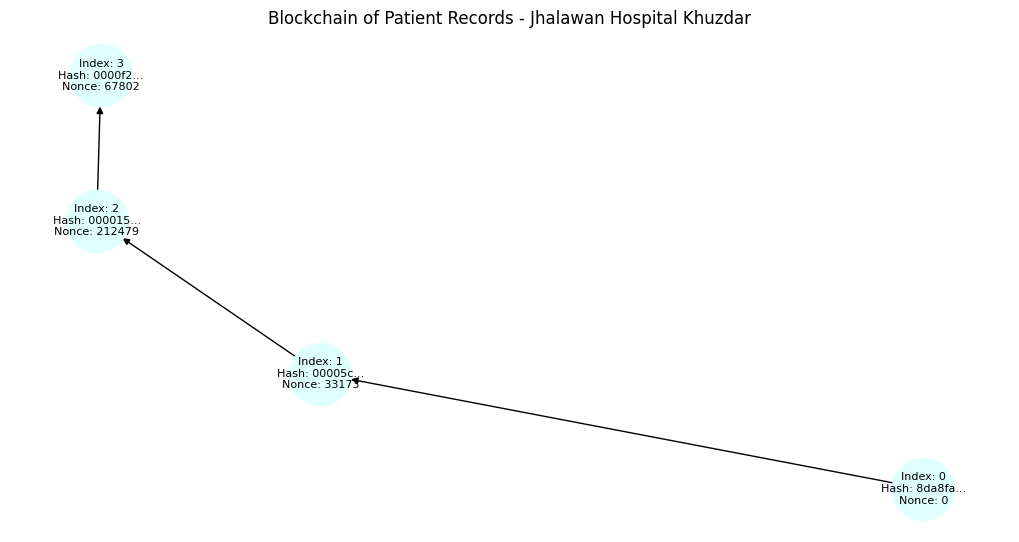

In [1]:
import hashlib
import datetime
import networkx as nx
import matplotlib.pyplot as plt

class Block:
    def __init__(self, index, timestamp, data, previous_hash):
        self.index = index
        self.timestamp = timestamp
        self.data = data
        self.previous_hash = previous_hash
        self.nonce = 0
        self.hash = self.calculate_hash()

    def calculate_hash(self):
        content = str(self.index) + str(self.timestamp) + str(self.data) + str(self.previous_hash) + str(self.nonce)
        return hashlib.sha256(content.encode()).hexdigest()

    def mine_block(self, difficulty):
        prefix = '0' * difficulty
        while self.hash[:difficulty] != prefix:
            self.nonce += 1
            self.hash = self.calculate_hash()

class Blockchain:
    def __init__(self):
        self.chain = [self.create_genesis_block()]
        self.difficulty = 4

    def create_genesis_block(self):
        return Block(0, datetime.datetime.now(), "Genesis Block", "0")

    def get_latest_block(self):
        return self.chain[-1]

    def add_block(self, new_block):
        new_block.previous_hash = self.get_latest_block().hash
        new_block.mine_block(self.difficulty)
        self.chain.append(new_block)

    def is_chain_valid(self):
        for i in range(1, len(self.chain)):
            curr = self.chain[i]
            prev = self.chain[i-1]
            if curr.hash != curr.calculate_hash() or curr.previous_hash != prev.hash:
                return False
        return True

def plot_blockchain(blockchain):
    G = nx.DiGraph()
    for block in blockchain.chain:
        label = f"Index: {block.index}\nHash: {block.hash[:6]}...\nNonce: {block.nonce}"
        G.add_node(block.index, label=label)
    for i in range(1, len(blockchain.chain)):
        G.add_edge(blockchain.chain[i-1].index, blockchain.chain[i].index)
    pos = nx.spring_layout(G, seed=42)
    labels = nx.get_node_attributes(G, 'label')
    plt.figure(figsize=(10,5))
    nx.draw(G, pos, with_labels=True, labels=labels, node_color='lightcyan', node_size=2000, font_size=8, arrows=True)
    plt.title("Blockchain of Patient Records - Jhalawan Hospital Khuzdar")
    plt.show()

# Patient data for 3 blocks - Jhalawan Hospital Khuzdar
patient_data = [
    {"hospital": "Jhalawan Hospital Khuzdar", "patient_name": "Ali", "diagnosis": "Flu"},
    {"hospital": "Jhalawan Hospital Khuzdar", "patient_name": "Muhammad", "diagnosis": "Cold"},
    {"hospital": "Jhalawan Hospital Khuzdar", "patient_name": "Ahmed", "diagnosis": "Diabetes"}
]

# Initialize blockchain and add blocks
blockchain = Blockchain()
for i, pdata in enumerate(patient_data, 1):
    print(f"Mining block {i} for patient {pdata['patient_name']}...")
    new_block = Block(i, datetime.datetime.now(), pdata, "")
    blockchain.add_block(new_block)

# Display blockchain details
for block in blockchain.chain:
    print(f"Index: {block.index} | Data: {block.data} | Hash: {block.hash}")

print("\nIs blockchain valid?", blockchain.is_chain_valid())

# Plot blockchain
plot_blockchain(blockchain)
